<a href="https://colab.research.google.com/github/AnshulKumar79/Freight_Rate_Prediction/blob/main/EDA_%26_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("train-test.csv")
df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [5]:
print(df.shape)
df.describe()

(48000, 14)


,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [6]:
df.isnull().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,300


In [8]:
df

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,TR-047996,Reno,Baton Rouge,39.54838,-118.64843,30.50134,-92.65374,1830.9,Flatbed,31786.0,2025-10-31,0.98865,2.05626,3787.32
47996,TR-047997,Greensboro,Memphis,35.98195,-82.78379,35.56802,-89.52871,445.8,Reefer,37465.0,2025-10-31,1.03034,1.51985,1171.93
47997,TR-047998,Greensboro,Cincinnati,35.98195,-82.78379,37.15706,-86.77499,267.9,Flatbed,24528.0,2025-10-31,1.00846,1.46954,713.36
47998,TR-047999,Memphis,Reno,35.56802,-89.52871,39.54838,-118.64843,1901.3,Flatbed,37581.0,2025-10-31,1.00014,2.05132,3987.46


In [10]:
df_new = df.drop('load_id', axis=1)
df_new.head()

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [16]:
print("pickup-locations: ",df_new["pickup"].unique().tolist())
print("delivery-locations: ",df_new["delivery"].unique().tolist())

pickup-locations:  ['Richmond', 'Philadelphia', 'Hartford', 'Dallas', 'Phoenix', 'Fresno', 'San Francisco', 'Bakersfield', 'Albuquerque', 'Harrisburg', 'Mobile', 'Nashville', 'Detroit', 'Albany', 'New Orleans', 'Reno', 'Austin', 'Chattanooga', 'Cincinnati', 'Syracuse', 'Atlanta', 'Oklahoma City', 'Lexington', 'Los Angeles', 'Providence', 'Madison', 'El Paso', 'Washington', 'Amarillo', 'Green Bay', 'Memphis', 'Baton Rouge', 'Kansas City', 'Fort Wayne', 'Charleston', 'Columbia', 'Grand Rapids', 'Jacksonville', 'Corpus Christi', 'Birmingham', 'Milwaukee', 'Tampa', 'Raleigh', 'Indianapolis', 'Baltimore', 'Boston', 'San Antonio', 'Montgomery', 'Buffalo', 'New York', 'Houston', 'Dayton', 'Toledo', 'Greensboro', 'Tulsa', 'Savannah', 'Shreveport', 'Lubbock', 'St. Louis', 'Little Rock', 'Louisville', 'Salt Lake City', 'Las Vegas', 'Tucson']
delivery-locations:  ['Baltimore', 'Philadelphia', 'Green Bay', 'Atlanta', 'Nashville', 'Corpus Christi', 'San Antonio', 'Kansas City', 'Montgomery', 'Phoen

In [17]:
df_new = df.drop(['load_id','pickup','delivery'], axis=1)
df_new.head()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [19]:
print("Equipments used: ",df_new["equipment"].unique().tolist())

Equipments used:  ['Dry Van', 'Reefer', 'Flatbed']


In [20]:
#encoding equipments
equipment_mapping = {'Dry Van': 1, 'Reefer': 2, 'Flatbed': 3}
df_new['equipments_encoded'] = df_new['equipment'].map(equipment_mapping)
df_new= df_new.drop('equipment', axis=1)
df_new.head()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate,equipments_encoded
0,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,2025-01-01,0.95684,2.39595,645.41,1
1,38.09122,-76.78906,39.22317,-72.96710,280.5,17555.0,2025-01-01,0.97623,2.43355,679.97,2
2,39.22317,-72.96710,44.30296,-87.52871,967.8,31721.0,2025-01-01,1.00971,1.84491,1802.54,1
3,39.55328,-72.18051,34.84933,-86.28940,965.4,32333.0,2025-01-01,0.94518,1.87712,1827.28,1
4,31.83025,-94.38343,35.29479,-88.08915,541.9,35183.0,2025-01-01,0.98480,2.56300,1380.28,2


In [21]:
df_new['date'] = pd.to_datetime(df_new['date'])
print(f"Data timeline ranges from {df_new['date'].min().date()} to {df_new['date'].max().date()}\n")

Data timeline ranges from 2025-01-01 to 2025-10-31



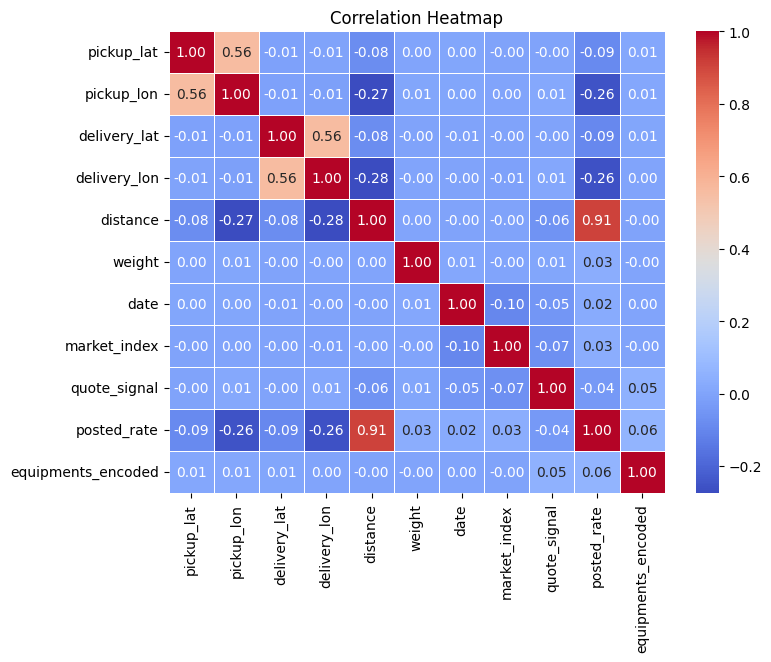

In [22]:
#checking correlation
corr = df_new.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [23]:
df_new

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate,equipments_encoded
0,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,2025-01-01,0.95684,2.39595,645.41,1
1,38.09122,-76.78906,39.22317,-72.96710,280.5,17555.0,2025-01-01,0.97623,2.43355,679.97,2
2,39.22317,-72.96710,44.30296,-87.52871,967.8,31721.0,2025-01-01,1.00971,1.84491,1802.54,1
3,39.55328,-72.18051,34.84933,-86.28940,965.4,32333.0,2025-01-01,0.94518,1.87712,1827.28,1
4,31.83025,-94.38343,35.29479,-88.08915,541.9,35183.0,2025-01-01,0.98480,2.56300,1380.28,2
...,...,...,...,...,...,...,...,...,...,...,...
47995,39.54838,-118.64843,30.50134,-92.65374,1830.9,31786.0,2025-10-31,0.98865,2.05626,3787.32,3
47996,35.98195,-82.78379,35.56802,-89.52871,445.8,37465.0,2025-10-31,1.03034,1.51985,1171.93,2
47997,35.98195,-82.78379,37.15706,-86.77499,267.9,24528.0,2025-10-31,1.00846,1.46954,713.36,3
47998,35.56802,-89.52871,39.54838,-118.64843,1901.3,37581.0,2025-10-31,1.00014,2.05132,3987.46,3


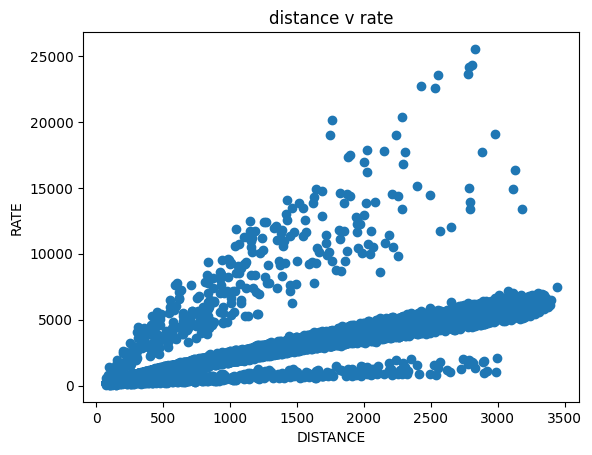

In [29]:
plt.scatter(df_new['distance'], df_new['posted_rate'])
plt.title('distance v rate')
plt.xlabel('DISTANCE')
plt.ylabel('RATE')

plt.show()

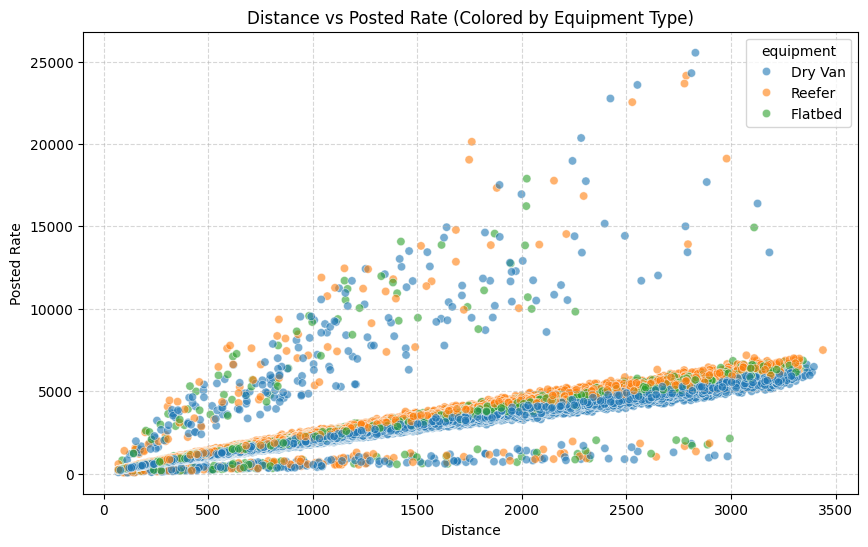

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance', y='posted_rate', hue='equipment', alpha=0.6)
plt.title('Distance vs Posted Rate (Colored by Equipment Type)')
plt.xlabel('Distance')
plt.ylabel('Posted Rate')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

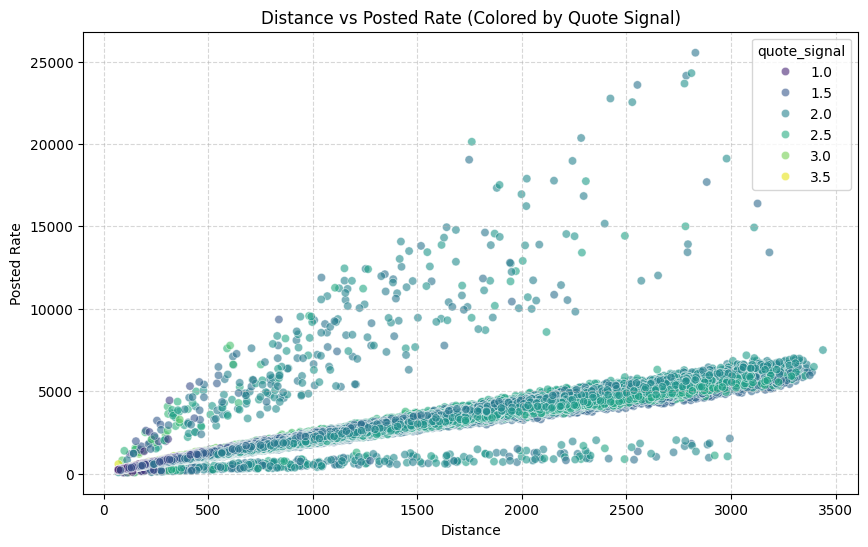

Number of rows with negative weights: 292
Summary of data with negative weights:


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
68,TR-000069,Amarillo,Dayton,33.17137,-104.36789,39.87206,-85.62931,1334.2,Reefer,-36559.0,2025-01-01,0.96102,2.11777,2831.27
204,TR-000205,Fresno,Tucson,33.07921,-119.79528,30.92733,-113.23037,496.2,Dry Van,-26670.0,2025-01-02,0.96903,2.13155,1046.92
206,TR-000207,Columbia,Raleigh,34.63570,-83.28506,35.37376,-77.47605,411.3,Reefer,-20003.0,2025-01-02,0.94800,2.31682,959.15
225,TR-000226,Greensboro,Lubbock,35.98195,-82.78379,29.87534,-99.85456,1317.4,Reefer,-23981.0,2025-01-02,1.00820,2.13918,2836.00
376,TR-000377,Madison,Providence,41.70243,-89.85588,37.37287,-69.50000,1331.1,Dry Van,-41397.0,2025-01-03,0.94787,1.91867,2522.54


In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance', y='posted_rate', hue='quote_signal', palette='viridis', alpha=0.6)
plt.title('Distance vs Posted Rate (Colored by Quote Signal)')
plt.xlabel('Distance')
plt.ylabel('Posted Rate')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Number of rows with negative weights:", (df['weight'] < 0).sum())
print("Summary of data with negative weights:")
df[df['weight'] < 0].head()

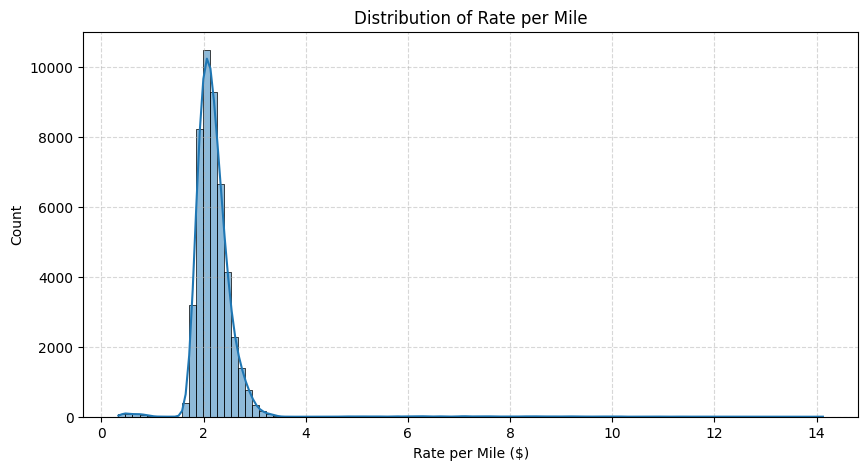

Rate per mile stats:
count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile, dtype: float64


In [32]:
# 1. Fix negative weights by converting them to absolute values
df['weight'] = df['weight'].abs()
df_new['weight'] = df_new['weight'].abs()

# 2. Calculate Rate per Mile to analyze the pricing structures
df_new['rate_per_mile'] = df_new['posted_rate'] / df_new['distance']

# 3. Plot the distribution of Rate per Mile to clearly see the distinct rate tiers
plt.figure(figsize=(10, 5))
sns.histplot(df_new['rate_per_mile'], bins=100, kde=True)
plt.title('Distribution of Rate per Mile')
plt.xlabel('Rate per Mile ($)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Show statistics on rate per mile
print("Rate per mile stats:")
print(df_new['rate_per_mile'].describe())

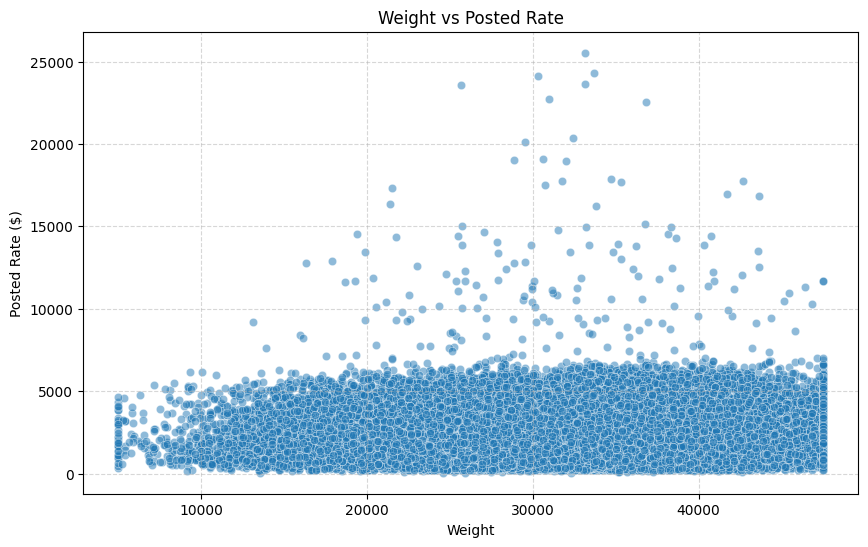

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='weight', y='posted_rate', alpha=0.5)
plt.title('Weight vs Posted Rate')
plt.xlabel('Weight')
plt.ylabel('Posted Rate ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [34]:
# Imputing missing values with median for robustness to outliers
weight_median = df_new['weight'].median()
market_median = df_new['market_index'].median()

df_new['weight'] = df_new['weight'].fillna(weight_median)
df_new['market_index'] = df_new['market_index'].fillna(market_median)

print("Remaining missing values in df_new:")
print(df_new.isnull().sum())

Remaining missing values in df_new:
pickup_lat            0
pickup_lon            0
delivery_lat          0
delivery_lon          0
distance              0
weight                0
date                  0
market_index          0
quote_signal          0
posted_rate           0
equipments_encoded    0
rate_per_mile         0
dtype: int64


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Feature Engineering: Extract date components
df_new['month'] = df_new['date'].dt.month
df_new['day_of_week'] = df_new['date'].dt.dayofweek

# Prepare features (X) and target (y)
# We drop 'posted_rate' (target) and 'rate_per_mile' (derived target leak) and 'date' (already converted)
X = df_new.drop(['posted_rate', 'rate_per_mile', 'date'], axis=1)
y = df_new['posted_rate']

# 2. Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train a Baseline Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Baseline Random Forest Performance:")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${np.sqrt(mse):.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Baseline Random Forest Performance:
Mean Absolute Error (MAE): $131.01
Root Mean Squared Error (RMSE): $570.73
R-squared (R2) Score: 0.8477


In [36]:
import lightgbm as lgb

# 1. Initialize and Train the LightGBM Regressor
lgb_model = lgb.LGBMRegressor(random_state=42, n_estimators=150, learning_rate=0.08, n_jobs=-1)
lgb_model.fit(X_train, y_train)

# 2. Predict and Evaluate
y_pred_lgb = lgb_model.predict(X_test)

mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)

print("LightGBM Performance:")
print(f"Mean Absolute Error (MAE): ${mae_lgb:.2f}")
print(f"Root Mean Squared Error (RMSE): ${np.sqrt(mse_lgb):.2f}")
print(f"R-squared (R2) Score: {r2_lgb:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1300
[LightGBM] [Info] Number of data points in the train set: 38400, number of used features: 11
[LightGBM] [Info] Start training from score 2372.113213
LightGBM Performance:
Mean Absolute Error (MAE): $120.51
Root Mean Squared Error (RMSE): $538.31
R-squared (R2) Score: 0.8645


/tmp/ipykernel_463/2389102948.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


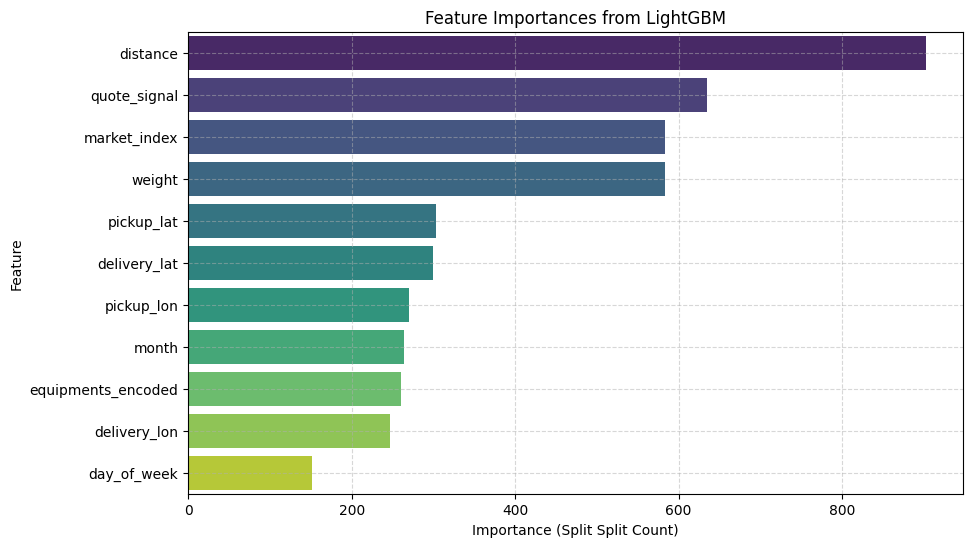

In [37]:
# Get feature importances from LightGBM
importances = lgb_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importances from LightGBM')
plt.xlabel('Importance (Split Split Count)')
plt.ylabel('Feature')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [38]:
import joblib

# Save the LightGBM model to a file
model_filename = 'lightgbm_rate_model.joblib'
joblib.dump(lgb_model, model_filename)
print(f"Successfully saved LightGBM model to {model_filename}!")

Successfully saved LightGBM model to lightgbm_rate_model.joblib!


In [39]:
import pandas as pd
import numpy as np
import joblib

# 1. Load validation data
val_df = pd.read_csv('validation.csv')
print("Validation set shape:", val_df.shape)

# Keep track of load_ids for the final output
output_df = pd.DataFrame({'load_id': val_df['load_id']})

# 2. Replicate preprocessing pipeline
# Handle negative weights
if 'weight' in val_df.columns:
    val_df['weight'] = val_df['weight'].abs()

# Impute missing values using the medians calculated during training
val_df['weight'] = val_df['weight'].fillna(weight_median)
val_df['market_index'] = val_df['market_index'].fillna(market_median)

# Map and encode equipment
val_df['equipments_encoded'] = val_df['equipment'].map(equipment_mapping)

# Extract date features
val_df['date'] = pd.to_datetime(val_df['date'])
val_df['month'] = val_df['date'].dt.month
val_df['day_of_week'] = val_df['date'].dt.dayofweek

# Drop columns not used as model features
features_to_drop = ['load_id', 'pickup', 'delivery', 'equipment', 'date']
X_val = val_df.drop(columns=[col for col in features_to_drop if col in val_df.columns])

# Align column ordering with the training set features (X.columns)
X_val = X_val[X.columns]

# 3. Load the saved model and predict
loaded_model = joblib.load('lightgbm_rate_model.joblib')
val_predictions = loaded_model.predict(X_val)

# 4. Save and display the predictions
output_df['predicted_posted_rate'] = val_predictions
display(output_df.head())

# Optionally save results to a CSV file
output_df.to_csv('validation_predictions.csv', index=False)
print("Predictions saved successfully to validation_predictions.csv!")

Validation set shape: (12000, 13)


,load_id,predicted_posted_rate
0,TE-000001,930.395044
1,TE-000002,5118.438171
2,TE-000003,5448.404503
3,TE-000004,4218.510093
4,TE-000005,1808.811025


Predictions saved successfully to validation_predictions.csv!
